Project

Use the most recent 756 daily returns at each estimate date. Estimate the first weights at the December 31, 2024 close. Re-estimate at each later month-end through June 30, 2026 and hold each weight vector over the following month’s daily returns. Estimate once more on July 31, 2026 for the final allocation decision.

A weight set at the close of date 
 first earns the return on the next trading day. Reset the equal-sleeve comparison on the same month-end dates. Ignore financing costs, transaction costs, taxes, and market impact.

Part 1.1: Verify the equal-sleeve portfolio’s long, short, gross, and net exposures. Report the position in each stock for $100 million of NAV.

In [5]:
import pandas as pd
import numpy as np

FILE = "project_situational_awareness_20260731.xlsx"

baseline = pd.read_excel(
    FILE,
    sheet_name="baseline weights"
)

baseline

,ticker,name,side,equal-sleeve weight
0,SNDK,Sandisk,long,0.333333
1,MU,Micron Technology,long,0.333333
2,VRT,Vertiv,long,0.333333
3,LITE,Lumentum,long,0.333333
4,COHR,Coherent,long,0.333333
5,BE,Bloom Energy,long,0.333333
6,ADBE,Adobe,short,-0.333333
7,CRM,Salesforce,short,-0.333333
8,ORCL,Oracle,short,-0.333333
9,NOW,ServiceNow,short,-0.333333


In [6]:
baseline = baseline.set_index("ticker")

w_equal = baseline["equal-sleeve weight"]

long_exposure = w_equal[w_equal > 0].sum()
short_exposure = w_equal[w_equal < 0].sum()
gross_exposure = w_equal.abs().sum()
net_exposure = w_equal.sum()

print(f"Long exposure:  {long_exposure:.2%}")
print(f"Short exposure: {short_exposure:.2%}")
print(f"Gross exposure: {gross_exposure:.2%}")
print(f"Net exposure:   {net_exposure:.2%}")

Long exposure:  200.00%
Short exposure: -200.00%
Gross exposure: 400.00%
Net exposure:   0.00%


In [11]:
NAV = 100000000 #100 million nav

positions = pd.DataFrame({
    "weight": w_equal,
    "position ($)": NAV * w_equal
})

positions.style.format({
    "weight": "{:.2%}",
    "position ($)": "{:,.2f}"
})

,weight,position ($)
ticker,,
SNDK,33.33%,"33,333,333.33"
MU,33.33%,"33,333,333.33"
VRT,33.33%,"33,333,333.33"
LITE,33.33%,"33,333,333.33"
COHR,33.33%,"33,333,333.33"
BE,33.33%,"33,333,333.33"
ADBE,-33.33%,"-33,333,333.33"
CRM,-33.33%,"-33,333,333.33"
ORCL,-33.33%,"-33,333,333.33"


Part 1.2: Using only returns available through December 31, 2024, report annualized mean, volatility, Sharpe ratio, and the correlation matrix for the 12 stocks. Identify one feature of the estimates that could make an unconstrained optimizer unreliable.

In [14]:
returns = pd.read_excel(
    FILE,
    sheet_name="total returns",
    index_col="Date",
    parse_dates=True
)

stocks = [
    "SNDK", "MU", "VRT", "LITE", "COHR", "BE",
    "ADBE", "CRM", "ORCL", "NOW", "WDAY", "MDB"
]

stock_returns = returns[stocks]

est_returns = stock_returns.loc[: "2024-12-31"].tail(756)

print(est_returns.index.min())
print(est_returns.index.max())
print(len(est_returns))

2021-12-29 00:00:00
2024-12-31 00:00:00
756


In [45]:
#calculate mean, vol, sharpe, stats
ann_mean = est_returns.mean() * 252
ann_vol = est_returns.std() * np.sqrt(252)
sharpe = ann_mean / ann_vol

#make dataframe of stats and display
stats = pd.DataFrame({
    "Annualized Mean": ann_mean,
    "Annualized Volatility": ann_vol,
    "Sharpe Ratio": sharpe
})
stats

,Annualized Mean,Annualized Volatility,Sharpe Ratio
SNDK,0.069359,0.417826,0.166001
MU,0.077045,0.455510,0.169139
VRT,0.711837,0.628390,1.132795
LITE,0.038393,0.480180,0.079956
COHR,0.269819,0.563573,0.478764
BE,0.306897,0.792823,0.387094
ADBE,-0.008353,0.382094,-0.021860
CRM,0.165476,0.383078,0.431964
ORCL,0.273021,0.309489,0.882167
NOW,0.248302,0.418231,0.593696


In [46]:
#correlation matrix
corr = est_returns.corr()
corr


,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
SNDK,1.000000,0.718547,0.438887,0.466519,0.490183,0.323291,0.407412,0.384610,0.339325,0.350159,0.297831,0.355324
MU,0.718547,1.000000,0.434841,0.469929,0.501027,0.314554,0.410147,0.400437,0.367142,0.384250,0.358434,0.363191
VRT,0.438887,0.434841,1.000000,0.407463,0.452319,0.303347,0.377112,0.397865,0.387464,0.421893,0.315579,0.401031
LITE,0.466519,0.469929,0.407463,1.000000,0.646837,0.306949,0.353031,0.403897,0.338876,0.365479,0.350723,0.331929
COHR,0.490183,0.501027,0.452319,0.646837,1.000000,0.293910,0.363246,0.363704,0.361128,0.377299,0.339895,0.362253
BE,0.323291,0.314554,0.303347,0.306949,0.293910,1.000000,0.252420,0.284910,0.234755,0.303490,0.279246,0.333016
ADBE,0.407412,0.410147,0.377112,0.353031,0.363246,0.252420,1.000000,0.610672,0.447802,0.650351,0.555527,0.508431
CRM,0.384610,0.400437,0.397865,0.403897,0.363704,0.284910,0.610672,1.000000,0.411900,0.713163,0.617409,0.502621
ORCL,0.339325,0.367142,0.387464,0.338876,0.361128,0.234755,0.447802,0.411900,1.000000,0.469581,0.372138,0.348297
NOW,0.350159,0.384250,0.421893,0.365479,0.377299,0.303490,0.650351,0.713163,0.469581,1.000000,0.643205,0.626946


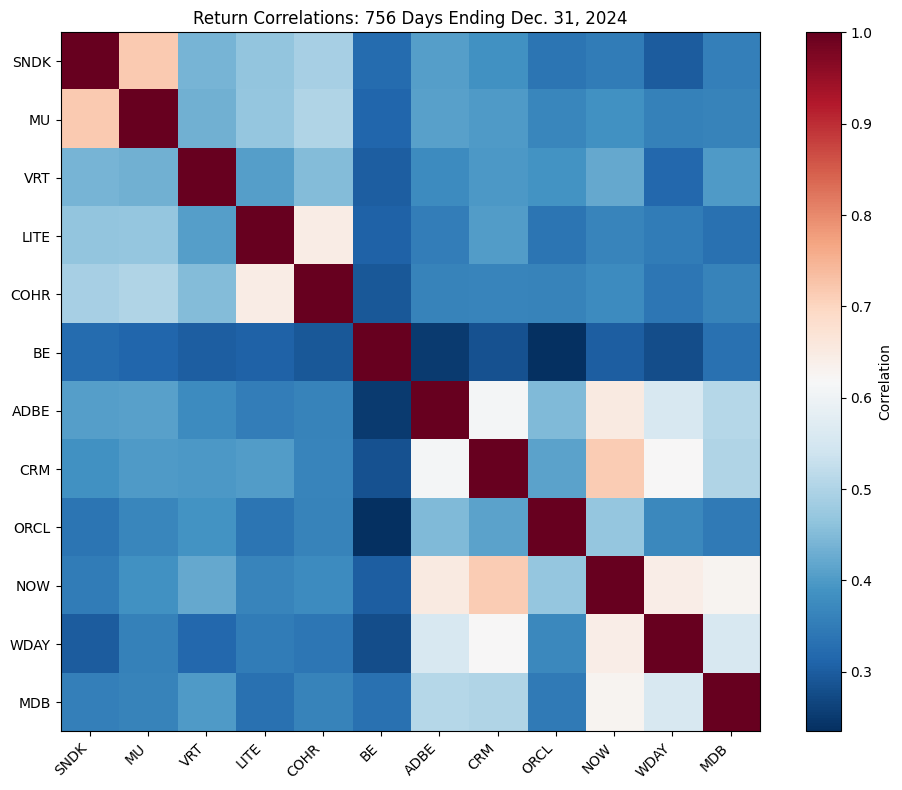

In [48]:
#make heatmap
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap="RdBu_r")

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")

ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Return Correlations: 756 Days Ending Dec. 31, 2024")

plt.tight_layout()
plt.show()

In [49]:
#check matrix and sharp ratios
print("condition number of covariance matrix:",
      np.linalg.cond(est_returns.cov()))
stats.sort_values("Sharpe Ratio", ascending=False)

condition number of covariance matrix: 34.73085258380912


,Annualized Mean,Annualized Volatility,Sharpe Ratio
VRT,0.711837,0.628390,1.132795
ORCL,0.273021,0.309489,0.882167
NOW,0.248302,0.418231,0.593696
COHR,0.269819,0.563573,0.478764
CRM,0.165476,0.383078,0.431964
BE,0.306897,0.792823,0.387094
MU,0.077045,0.455510,0.169139
SNDK,0.069359,0.417826,0.166001
WDAY,0.053802,0.391505,0.137425
LITE,0.038393,0.480180,0.079956


On optimizer unreliability:

The estimates contain substantial estimation risk in the sample means. Expected returns are estimated from only daily observations and can differ materially across stocks due to a lot of sampling noise. Because the tangency portfolio depends directly on the sample mean, small errors in estimated means or covariances can translate into very large and unstable portfolio weights. This makes an unconstrained optimizer particularly vulnerable to extreme positions. Small changes in an estimated expected return can cause enormous changes in optimal weights, particularly when securities are correlated.

Part 2.1: Used position cap stabilizer, which uses the sample mean and covariance matrix. We added constraints and boundaries so that the absolute positions are no more than 50% of NAV. 

The portfolio maximizes its estimated Sharpe ratio using the sample mean and covariance matrix from the daily returns ending 12/31/2024 and 0 risk-free rate. The position cap is intended to reduce sensitivity to noisy expected-return and covariance estimates by preventing the optimizer from concentrating excessively in securities that appear unusually attractive in-sample.

In [24]:
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# Estimates from the 756 days ending 2024-12-31
mu = est_returns.mean() * 252
Sigma = est_returns.cov() * 252

stocks = list(est_returns.columns)

long_tickers = ["SNDK", "MU", "VRT", "LITE", "COHR", "BE"]
short_tickers = ["ADBE", "CRM", "ORCL", "NOW", "WDAY", "MDB"]

long_idx = [stocks.index(t) for t in long_tickers]
short_idx = [stocks.index(t) for t in short_tickers]

#define negative sharpe
def neg_sharpe(w, mu, Sigma):
    port_mean = w @ mu
    port_vol = np.sqrt(w @ Sigma @ w)
    return -port_mean / port_vol

#equal sleeve portfolio
x0 = w_equal.reindex(stocks).values

#add constriants and bounds
constraints = [
    {
        "type": "eq",
        "fun": lambda w: w[long_idx].sum() - 2
    },
    {
        "type": "eq",
        "fun": lambda w: w[short_idx].sum() + 2
    }
]

bounds = [
    (0, 0.5) if ticker in long_tickers
    else (-0.5, 0)
    for ticker in stocks
]

#generate minimized result
result = minimize(
    neg_sharpe,
    x0,
    args=(mu.values, Sigma.values),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
    options={
        "ftol": 1e-12,
        "maxiter": 1000
    }
)

#check success
print("success?", result.success)
print("msg", result.message)

#get weights
w_opt = pd.Series(
    result.x,
    index=stocks,
    name="optimized weight"
)

w_opt

success? True
msg Optimization terminated successfully


SNDK    1.969018e-01
MU      3.030982e-01
VRT     5.000000e-01
LITE    4.160333e-16
COHR    5.000000e-01
BE      5.000000e-01
ADBE   -5.000000e-01
CRM    -5.000000e-01
ORCL   -1.694426e-17
NOW    -3.283398e-17
WDAY   -5.000000e-01
MDB    -5.000000e-01
Name: optimized weight, dtype: float64

In [25]:
#check exposures
long_exposure = w_opt[w_opt > 0].sum()
short_exposure = w_opt[w_opt < 0].sum()
gross_exposure = w_opt.abs().sum()
net_exposure = w_opt.sum()
largest_position = w_opt.abs().max()

print(f"Long exposure:    {long_exposure:.6f}")
print(f"Short exposure:   {short_exposure:.6f}")
print(f"Gross exposure:   {gross_exposure:.6f}")
print(f"Net exposure:     {net_exposure:.6f}")
print(f"Largest position: {largest_position:.6f}")

Long exposure:    2.000000
Short exposure:   -2.000000
Gross exposure:   4.000000
Net exposure:     0.000000
Largest position: 0.500000


In [27]:
#verification

tol = 1e-8

checks = {
    "optimizer succeeded": result.success,
    "long exposure = +2": np.isclose(
        w_opt.loc[long_tickers].sum(), 2, atol=tol
    ),
    "short exposure = -2": np.isclose(
        w_opt.loc[short_tickers].sum(), -2, atol=tol
    ),
    "gross exposure = 4": np.isclose(
        w_opt.abs().sum(), 4, atol=tol
    ),
    "net exposure = 0": np.isclose(
        w_opt.sum(), 0, atol=tol
    ),
    "position cap satisfied": (w_opt.abs() <= 0.5 + tol).all()
}

pd.Series(checks)

optimizer succeeded       True
long exposure = +2        True
short exposure = -2       True
gross exposure = 4        True
net exposure = 0          True
position cap satisfied    True
dtype: bool

In [ ]:
#check portfolio stats
def portfolio_stats(w, mu, Sigma):
    mean = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    sharpe = mean / vol
    return mean, vol, sharpe

eq_mean, eq_vol, eq_sharpe = portfolio_stats(
    x0, mu.values, Sigma.values
)

opt_mean, opt_vol, opt_sharpe = portfolio_stats(
    result.x, mu.values, Sigma.values
)

print(f"Equal-sleeve estimated Sharpe: {eq_sharpe:.3f}")
print(f"Optimized estimated Sharpe:    {opt_sharpe:.3f}")

Equal-sleeve estimated Sharpe: 0.392
Optimized estimated Sharpe:    0.778


Part 2.2 Numeric Pass Fail Criteria

1. Pass if annualized one-way turnover is no greater than 300% of NAV
- One way turnover is total buys or total sells, defined as 1/2 the sum of weight changes
- Passes if its annualized one-way turnover < 300% NAV. This corresponds to average monthly turnover of 25% of NAV. Because the optimization is re-estimated monthly from noisy historical estimates, substantially higher turnover would show optimizer reacting excessively to small changes in estimated inputs rather than producing a stable allocation.


2. Pass if its realized out-of-sample Sharpe exceeds the equal-sleeve Sharpe by at least 0.20
- Passes if SR(test) - SR(equal) >= 0.2
- Passes if realized Sharpe ratio from the post-2024 test period > the equal-sleeve portfolio's Sharpe ratio by at least 0.20. Because the optimizer explicitly maximizes estimated Sharpe ratio, its out-of-sample success should be judged on the same risk-adjusted basis. Requiring a 0.20 improvement makes sure evidence of optimization materially improved the portfolio.


Conclusion: Ex-ante replacement criteria. Before examining any portfolio returns after 12/31/2024 we specify two criteria for replacing the equal-sleeve allocation. First, the optimized portfolio must have annualized one-way turnover no greater than 300% of NAV. Second, its realized post-2024 Sharpe ratio must exceed that of the equal-sleeve portfolio by at least 0.20. We will recommend replacing the old portfolio only if both criteria are satisfied.

Part 3.1: Use the 756 returns ending December 31, 2024 to estimate the optimized weights. Compare them with equal sleeves. Report long, short, gross, and net exposure; the largest absolute position; and the estimated annualized mean, volatility, and Sharpe ratio.

In [28]:
#comparison table of optimized weights
comparison = pd.DataFrame({
    "Equal Sleeve": w_equal.reindex(stocks),
    "Optimized": w_opt
})

comparison["Change"] = comparison["Optimized"] - comparison["Equal Sleeve"]

display(
    comparison.style.format({
        "Equal Sleeve": "{:.2%}",
        "Optimized": "{:.2%}",
        "Change": "{:+.2%}"
    })
)

,Equal Sleeve,Optimized,Change
SNDK,33.33%,19.69%,-13.64%
MU,33.33%,30.31%,-3.02%
VRT,33.33%,50.00%,+16.67%
LITE,33.33%,0.00%,-33.33%
COHR,33.33%,50.00%,+16.67%
BE,33.33%,50.00%,+16.67%
ADBE,-33.33%,-50.00%,-16.67%
CRM,-33.33%,-50.00%,-16.67%
ORCL,-33.33%,-0.00%,+33.33%
NOW,-33.33%,-0.00%,+33.33%


In [ ]:
#exposure checks
long_exposure = w_opt.loc[long_tickers].sum()
short_exposure = w_opt.loc[short_tickers].sum()
gross_exposure = w_opt.abs().sum()
net_exposure = w_opt.sum()
largest_position = w_opt.abs().max()
largest_ticker = w_opt.abs().idxmax()

print(f"Long exposure:       {long_exposure:.2%}")
print(f"Short exposure:      {short_exposure:.2%}")
print(f"Gross exposure:      {gross_exposure:.2%}")
print(f"Net exposure:        {net_exposure:.2%}")
print(f"Largest absolute position:    {largest_position:.2%} ({largest_ticker})")

Long exposure:       200.00%
Short exposure:      -200.00%
Gross exposure:      400.00%
Net exposure:        0.00%
Largest position:    50.00% (BE)


In [ ]:
#estimated portfolio stats comparison

eq_mean, eq_vol, eq_sharpe = portfolio_stats(
    w_equal.reindex(stocks).values,
    mu.values,
    Sigma.values
)

opt_mean, opt_vol, opt_sharpe = portfolio_stats(
    w_opt.values,
    mu.values,
    Sigma.values
)

#original
print("Equal sleeves")
print(f"Annualized mean: {eq_mean:.2%}")
print(f"Annualized vol:  {eq_vol:.2%}")
print(f"Sharpe:          {eq_sharpe:.3f}")

#optimized
print("\nOptimized")
print(f"Annualized mean: {opt_mean:.2%}")
print(f"Annualized vol:  {opt_vol:.2%}")
print(f"Sharpe:          {opt_sharpe:.3f}")

Equal sleeves
Annualized mean: 25.76%
Annualized vol:  65.67%
Sharpe:          0.392

Optimized
Annualized mean: 59.17%
Annualized vol:  76.10%
Sharpe:          0.778


Part 3.2: Identify the two largest changes from equal sleeves. Trace each change to estimated mean, volatility, or covariance rather than describing the company alone.

In [ ]:
top2 = comparison["Change"].abs().nlargest(3).index
#there is actually a tie for top 2, with ORCL NOW and LITE all changing 33.33pp, so I chose to show all three here

explanation_table = pd.DataFrame({
    "Equal Weight": w_equal.reindex(stocks),
    "Optimized Weight": w_opt,
    "Change": w_opt - w_equal.reindex(stocks),
    "Annualized Mean": mu,
    "Annualized Volatility": np.sqrt(np.diag(Sigma)),
    "Sharpe": mu / np.sqrt(np.diag(Sigma))
}).loc[top2]

explanation_table

,Equal Weight,Optimized Weight,Change,Annualized Mean,Annualized Volatility,Sharpe
ORCL,-0.333333,-1.694426e-17,0.333333,0.273021,0.309489,0.882167
NOW,-0.333333,-3.283398e-17,0.333333,0.248302,0.418231,0.593696
LITE,0.333333,4.160333e-16,-0.333333,0.038393,0.480180,0.079956


In [43]:
#diagnostics table
diagnostics = comparison.copy()

diagnostics["Annualized Mean"] = mu
diagnostics["Annualized Vol"] = np.sqrt(np.diag(Sigma))

diagnostics = diagnostics.loc[
    diagnostics["Change"].abs().sort_values(ascending=False).index
]

diagnostics


,Equal Sleeve,Optimized,Change,Annualized Mean,Annualized Vol
ORCL,-0.333333,-1.694426e-17,0.333333,0.273021,0.309489
NOW,-0.333333,-3.283398e-17,0.333333,0.248302,0.418231
LITE,0.333333,4.160333e-16,-0.333333,0.038393,0.480180
BE,0.333333,5.000000e-01,0.166667,0.306897,0.792823
CRM,-0.333333,-5.000000e-01,-0.166667,0.165476,0.383078
WDAY,-0.333333,-5.000000e-01,-0.166667,0.053802,0.391505
COHR,0.333333,5.000000e-01,0.166667,0.269819,0.563573
ADBE,-0.333333,-5.000000e-01,-0.166667,-0.008353,0.382094
MDB,-0.333333,-5.000000e-01,-0.166667,-0.031711,0.707892
VRT,0.333333,5.000000e-01,0.166667,0.711837,0.628390


In [44]:
#look at correlation of our top 2
corr.loc[top2]

,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
ORCL,0.339325,0.367142,0.387464,0.338876,0.361128,0.234755,0.447802,0.411900,1.000000,0.469581,0.372138,0.348297
NOW,0.350159,0.384250,0.421893,0.365479,0.377299,0.303490,0.650351,0.713163,0.469581,1.000000,0.643205,0.626946
LITE,0.466519,0.469929,0.407463,1.000000,0.646837,0.306949,0.353031,0.403897,0.338876,0.365479,0.350723,0.331929


ORCL: goes from −33.33% to ~0%. Its estimated annual mean return is +27.30% with annualized volatility of only 30.95%, producing a standalone Sharpe ratio of 0.88. Because ORCL belongs to the short sleeve, this strongly positive estimated return makes a negative ORCL weight unattractive: the short position would reduce the portfolio's estimated expected return. The optimizer therefore eliminates the ORCL short and shifts the required −200% short exposure toward securities with less favorable estimated return distributions.

NOW: similarly to ORCL, went from -33.33% to ~0%. It's estimated annual mean return is +24.83% with volatility of 41.82% producing a sharpe of 0.59, and its correlations with the other software shorts like CRM, ADBE, WDAY, etc.. are pretty high. Thus the optimizer removes it.

LITE: on the long side, this goes from +33.33% to 0%. Its estimated annual return is only 3.84% despite annualized volatility of 48.02%, giving it a standalone Sharpe ratio of just 0.08. Relative to other long-side securities, the estimated return does not compensate for its risk, so the optimizer removes the position and reallocates the long sleeve toward securities with more favorable estimated mean-risk combinations.

Part 4.1: Re-estimate the optimized portfolio at each month-end in the stated test period. Plot all 12 weights. Verify that every weight vector satisfies the mandate and, if applicable, the position cap.

In [50]:
#build the month-end estimate grid: first weights at 12/31/2024, a re-estimate at every later
#month-end through 6/30/2026, and one final estimate on 7/31/2026 for the Part 6.2 decision
calendar = stock_returns.loc["2024-12-01":"2026-07-31"].index
est_dates = sorted(calendar.to_series().groupby([calendar.year, calendar.month]).max())

FINAL_DATE = est_dates[-1]      #7/31/2026, estimated but never held inside the test
hold_dates = est_dates[:-1]     #12/31/2024 through 6/30/2026, each held one month
WINDOW = 756

print(f"{len(est_dates)} estimate dates from {est_dates[0].date()} to {est_dates[-1].date()}")
print(f"{len(hold_dates)} of them are held over the following month's daily returns")

20 estimate dates from 2024-12-31 to 2026-07-31
19 of them are held over the following month's daily returns


In [51]:
#at each estimate date, re-run the exact Part 2.1 problem on the trailing 756 daily returns
def estimate_inputs(date):
    est = stock_returns.loc[:date].tail(WINDOW)
    return est.mean() * 252, est.cov() * 252, est


def optimize(mu_t, Sigma_t):
    return minimize(
        neg_sharpe,
        w_equal.reindex(stocks).values,
        args=(mu_t.values, Sigma_t.values),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 1000}
    )


weight_rows, mu_rows, vol_rows, opt_results, window_start = {}, {}, {}, {}, {}

for date in est_dates:
    mu_t, Sigma_t, est_t = estimate_inputs(date)
    result = optimize(mu_t, Sigma_t)

    weight_rows[date] = pd.Series(result.x, index=stocks)
    mu_rows[date] = mu_t
    vol_rows[date] = pd.Series(np.sqrt(np.diag(Sigma_t)), index=stocks)
    opt_results[date] = result
    window_start[date] = est_t.index[0]

weights_opt = pd.DataFrame(weight_rows).T
weights_opt.index.name = "estimate date"
mu_hist = pd.DataFrame(mu_rows).T
vol_hist = pd.DataFrame(vol_rows).T

#every window is a full 756 observations, so no estimate is built on a short sample
print("estimation windows all 756 days:",
      all(len(stock_returns.loc[:d].tail(WINDOW)) == WINDOW for d in est_dates))
print(f"first window starts {window_start[est_dates[0]].date()}, "
      f"last window starts {window_start[FINAL_DATE].date()}")

weights_opt.style.format("{:.2%}")

estimation windows all 756 days: True
first window starts 2021-12-29, last window starts 2023-07-27


,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
estimate date,,,,,,,,,,,,
2024-12-31 00:00:00,19.69%,30.31%,50.00%,0.00%,50.00%,50.00%,-50.00%,-50.00%,0.00%,-0.00%,-50.00%,-50.00%
2025-01-31 00:00:00,33.56%,16.44%,50.00%,0.00%,50.00%,50.00%,-50.00%,-41.19%,-8.81%,-0.00%,-50.00%,-50.00%
2025-02-28 00:00:00,50.00%,5.44%,50.00%,0.00%,44.56%,50.00%,-50.00%,-50.00%,0.00%,0.00%,-50.00%,-50.00%
2025-03-31 00:00:00,50.00%,48.39%,50.00%,0.00%,21.98%,29.63%,-50.00%,-49.73%,-0.27%,0.00%,-50.00%,-50.00%
2025-04-30 00:00:00,0.00%,50.00%,50.00%,0.00%,50.00%,50.00%,-50.00%,-22.43%,-27.57%,0.00%,-50.00%,-50.00%
2025-05-30 00:00:00,0.00%,50.00%,50.00%,0.00%,50.00%,50.00%,-50.00%,-50.00%,0.00%,0.00%,-50.00%,-50.00%
2025-06-30 00:00:00,16.42%,50.00%,50.00%,0.00%,50.00%,33.58%,-50.00%,-50.00%,-0.00%,0.00%,-50.00%,-50.00%
2025-07-31 00:00:00,0.00%,50.00%,50.00%,0.00%,50.00%,50.00%,-50.00%,-50.00%,-0.00%,-0.00%,-50.00%,-50.00%
2025-08-29 00:00:00,12.47%,50.00%,50.00%,0.00%,38.54%,49.00%,-50.00%,-50.00%,0.00%,-3.91%,-50.00%,-46.09%


In [52]:
#re-check the mandate and the position cap at every single estimate date
mandate = pd.DataFrame({
    "Long": weights_opt[long_tickers].sum(axis=1),
    "Short": weights_opt[short_tickers].sum(axis=1),
    "Gross": weights_opt.abs().sum(axis=1),
    "Net": weights_opt.sum(axis=1),
    "Largest |weight|": weights_opt.abs().max(axis=1),
    "Estimated Sharpe": [
        portfolio_stats(weights_opt.loc[d].values,
                        mu_hist.loc[d].values,
                        estimate_inputs(d)[1].values)[2]
        for d in weights_opt.index
    ]
})

tol = 1e-8

checks = {
    "optimizer succeeded at every date": all(r.success for r in opt_results.values()),
    "long exposure = +2 everywhere": np.isclose(mandate["Long"], 2, atol=tol).all(),
    "short exposure = -2 everywhere": np.isclose(mandate["Short"], -2, atol=tol).all(),
    "gross exposure = 4 everywhere": np.isclose(mandate["Gross"], 4, atol=tol).all(),
    "net exposure = 0 everywhere": np.isclose(mandate["Net"], 0, atol=tol).all(),
    "position cap satisfied everywhere": (weights_opt.abs() <= 0.5 + tol).all().all()
}

display(pd.Series(checks))

display(
    mandate.style.format({
        "Long": "{:.4f}",
        "Short": "{:.4f}",
        "Gross": "{:.4f}",
        "Net": "{:+.1e}",
        "Largest |weight|": "{:.2%}",
        "Estimated Sharpe": "{:.3f}"
    })
)

optimizer succeeded at every date    True
long exposure = +2 everywhere        True
short exposure = -2 everywhere       True
gross exposure = 4 everywhere        True
net exposure = 0 everywhere          True
position cap satisfied everywhere    True
dtype: bool

,Long,Short,Gross,Net,Largest |weight|,Estimated Sharpe
estimate date,,,,,,
2024-12-31 00:00:00,2.0000,-2.0000,4.0000,+1.1e-16,50.00%,0.778
2025-01-31 00:00:00,2.0000,-2.0000,4.0000,+5.6e-16,50.00%,0.725
2025-02-28 00:00:00,2.0000,-2.0000,4.0000,-2.2e-16,50.00%,0.658
2025-03-31 00:00:00,2.0000,-2.0000,4.0000,-2.8e-16,50.00%,0.737
2025-04-30 00:00:00,2.0000,-2.0000,4.0000,+0.0e+00,50.00%,0.695
2025-05-30 00:00:00,2.0000,-2.0000,4.0000,-2.2e-16,50.00%,0.701
2025-06-30 00:00:00,2.0000,-2.0000,4.0000,-1.1e-16,50.00%,0.959
2025-07-31 00:00:00,2.0000,-2.0000,4.0000,-2.2e-16,50.00%,1.072
2025-08-29 00:00:00,2.0000,-2.0000,4.0000,+5.6e-17,50.00%,0.981


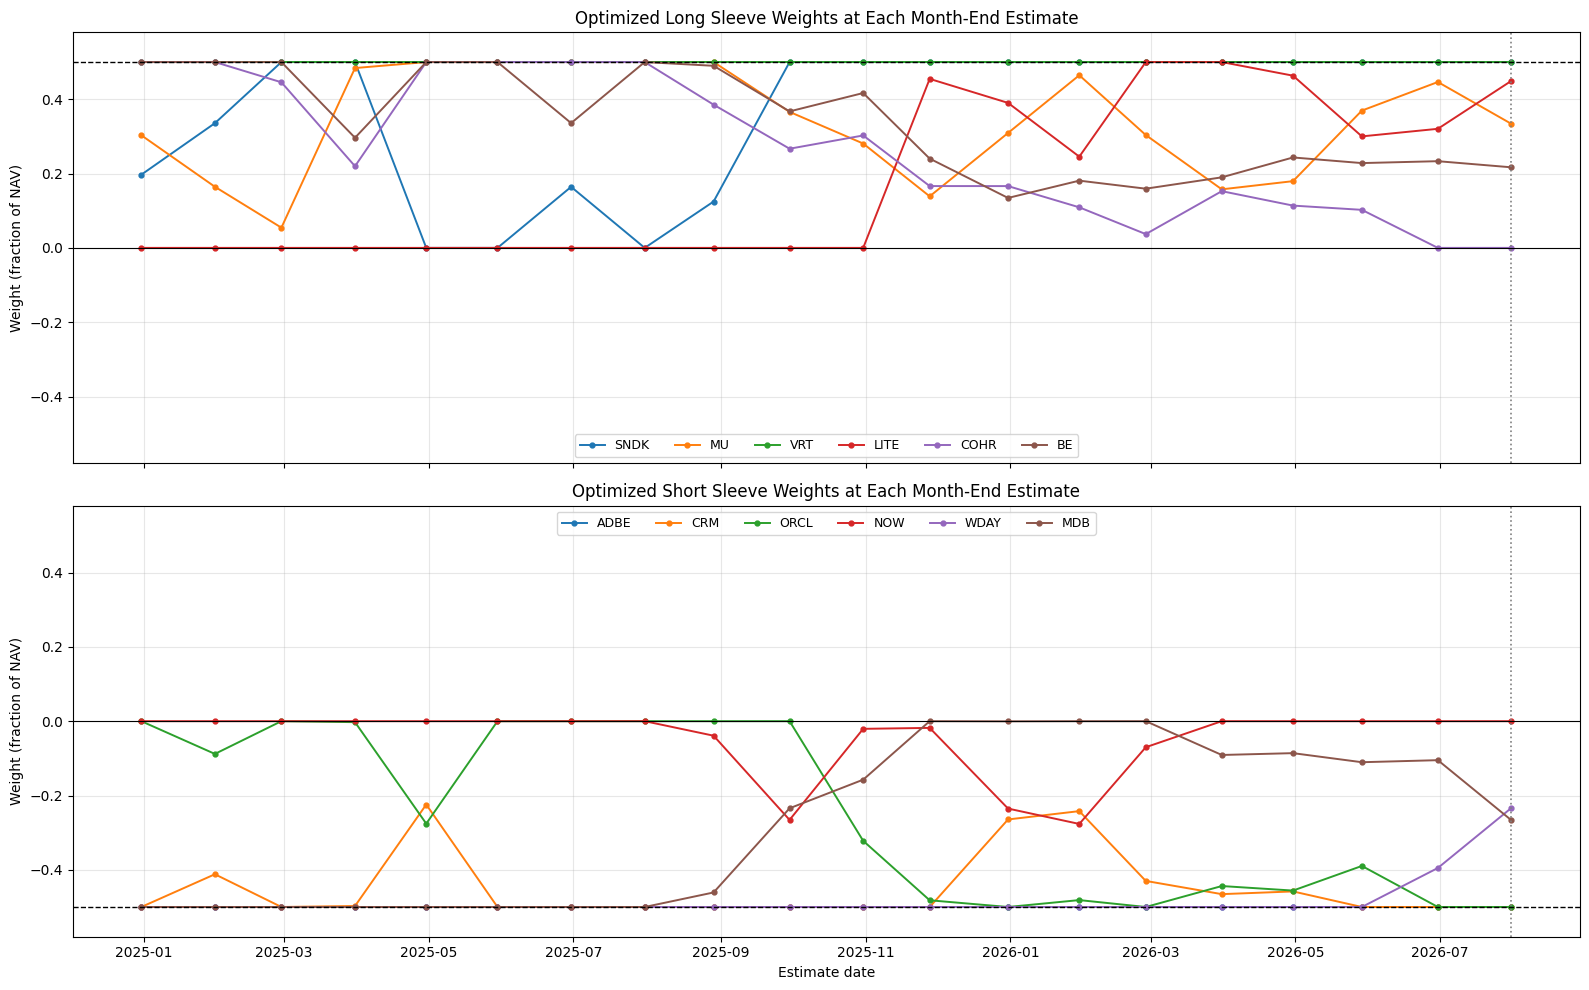

Dashed lines are the +/-50% position cap. The dotted vertical line is the 7/31/2026 estimate, which is used only for the final allocation decision and is never held.


In [53]:
#plot all 12 weight paths, one sleeve per panel so the cap is readable on both
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True, sharey=True)

for ticker in long_tickers:
    axes[0].plot(weights_opt.index, weights_opt[ticker],
                 marker="o", markersize=3.5, linewidth=1.4, label=ticker)
axes[0].set_title("Optimized Long Sleeve Weights at Each Month-End Estimate")

for ticker in short_tickers:
    axes[1].plot(weights_opt.index, weights_opt[ticker],
                 marker="o", markersize=3.5, linewidth=1.4, label=ticker)
axes[1].set_title("Optimized Short Sleeve Weights at Each Month-End Estimate")
axes[1].set_xlabel("Estimate date")

for ax, cap, legend_loc in [(axes[0], 0.5, "lower center"), (axes[1], -0.5, "upper center")]:
    ax.axhline(cap, color="black", linestyle="--", linewidth=1)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(FINAL_DATE, color="grey", linestyle=":", linewidth=1.2)
    ax.set_ylabel("Weight (fraction of NAV)")
    ax.set_ylim(-0.58, 0.58)
    ax.legend(ncol=6, fontsize=9, loc=legend_loc)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Dashed lines are the +/-50% position cap. The dotted vertical line is the 7/31/2026 "
      "estimate, which is used only for the final allocation decision and is never held.")

On the rolling weights:

All 20 monthly problems solve successfully, and every weight vector satisfies the mandate exactly: the long sleeve sums to +2, the short sleeve sums to -2, gross exposure is 400% of NAV, net exposure is zero to machine precision, and no absolute position exceeds the 50% cap.

The plot shows that the cap is doing the real work. Most weights sit on a boundary rather than in the interior, with VRT pinned at +50% and ADBE at -50% at every single date, which is the signature of an estimated tangency portfolio that would take far more extreme positions if allowed to. Because five or six names are usually pinned, the residual exposure needed to hit +2 and -2 falls on the one or two positions that happen to be free that month, so a small change in the estimates becomes a large change in those weights. This is the instability Part 1.2 flagged, held in check by the constraint rather than by the estimates themselves.

Part 4.2: Report each stock's minimum and maximum weight and the portfolio's annualized one-way turnover. Identify the two largest month-to-month changes in the weight vector and trace them to changes in the estimates.

In [54]:
#range of each stock's weight across the 20 estimate dates
weight_range = pd.DataFrame({
    "Minimum": weights_opt.min(),
    "Maximum": weights_opt.max(),
    "Range": weights_opt.max() - weights_opt.min(),
    "Mean": weights_opt.mean(),
    "Equal sleeve": w_equal.reindex(stocks),
    "Months at a boundary": (weights_opt.abs() >= 0.5 - tol).sum() + (weights_opt.abs() <= tol).sum()
})

weight_range.style.format({
    "Minimum": "{:.2%}",
    "Maximum": "{:.2%}",
    "Range": "{:.2%}",
    "Mean": "{:.2%}",
    "Equal sleeve": "{:.2%}",
    "Months at a boundary": "{:.0f}"
})

,Minimum,Maximum,Range,Mean,Equal sleeve,Months at a boundary
SNDK,0.00%,50.00%,50.00%,36.61%,33.33%,16
MU,5.44%,50.00%,44.56%,34.28%,33.33%,5
VRT,50.00%,50.00%,0.00%,50.00%,33.33%,20
LITE,0.00%,50.00%,50.00%,18.12%,33.33%,13
COHR,0.00%,50.00%,50.00%,27.34%,33.33%,8
BE,13.44%,50.00%,36.56%,33.66%,33.33%,6
ADBE,-50.00%,-50.00%,0.00%,-50.00%,-33.33%,20
CRM,-50.00%,-22.43%,27.57%,-44.97%,-33.33%,12
ORCL,-50.00%,0.00%,50.00%,-24.70%,-33.33%,11
NOW,-27.65%,0.00%,27.65%,-4.63%,-33.33%,13


In [55]:
#one-way turnover is total buys or total sells, i.e. half the sum of absolute weight changes.
#only the 18 transitions between held weight vectors count; the 7/31/2026 estimate is never traded
held_weights = weights_opt.loc[hold_dates]
weight_changes = held_weights.diff().dropna()
one_way = weight_changes.abs().sum(axis=1) / 2

turnover_annualized = one_way.mean() * 12

print(f"{len(one_way)} monthly rebalances between held weight vectors")
print(f"Average monthly one-way turnover: {one_way.mean():.2%} of NAV")
print(f"Annualized one-way turnover:      {turnover_annualized:.2%} of NAV")
print(f"Part 2.2 threshold:               300.00% of NAV")
print(f"Criterion 1 (turnover <= 300%):   {'PASS' if turnover_annualized <= 3.0 else 'FAIL'}")

display(one_way.to_frame("one-way turnover").style.format("{:.2%}"))

18 monthly rebalances between held weight vectors
Average monthly one-way turnover: 33.42% of NAV
Annualized one-way turnover:      401.04% of NAV
Part 2.2 threshold:               300.00% of NAV
Criterion 1 (turnover <= 300%):   FAIL


,one-way turnover
estimate date,
2025-01-31 00:00:00,22.68%
2025-02-28 00:00:00,25.25%
2025-03-31 00:00:00,43.22%
2025-04-30 00:00:00,77.31%
2025-05-30 00:00:00,27.57%
2025-06-30 00:00:00,16.42%
2025-07-31 00:00:00,16.42%
2025-08-29 00:00:00,16.38%
2025-09-30 00:00:00,60.18%


In [56]:
#the two largest month-to-month changes in the weight vector
largest_moves = one_way.nlargest(2)

print("Two largest month-to-month changes in the weight vector")
display(largest_moves.to_frame("one-way turnover").style.format("{:.2%}"))

for date in largest_moves.index:
    previous = held_weights.index[held_weights.index.get_loc(date) - 1]

    #covariance enters through the correlation with the sleeve the position has to sit alongside
    est_new = estimate_inputs(date)[2]
    long_leg = est_new[long_tickers].mean(axis=1)

    trace = pd.DataFrame({
        "Weight (prior)": held_weights.loc[previous],
        "Weight (new)": held_weights.loc[date],
        "Weight change": held_weights.loc[date] - held_weights.loc[previous],
        "Est. mean (prior)": mu_hist.loc[previous],
        "Est. mean (new)": mu_hist.loc[date],
        "Est. mean change": mu_hist.loc[date] - mu_hist.loc[previous],
        "Est. vol (new)": vol_hist.loc[date],
        "Est. Sharpe (prior)": mu_hist.loc[previous] / vol_hist.loc[previous],
        "Est. Sharpe (new)": mu_hist.loc[date] / vol_hist.loc[date],
        "Corr. with long sleeve (new)": est_new.corrwith(long_leg)
    })
    trace = trace[trace["Weight change"].abs() > 1e-6]
    trace = trace.reindex(trace["Weight change"].abs().sort_values(ascending=False).index)

    print(f"\n{previous.date()} -> {date.date()}   "
          f"(estimation window rolls from {window_start[previous].date()} "
          f"to {window_start[date].date()})")
    display(
        trace.style.format({
            "Weight (prior)": "{:.2%}",
            "Weight (new)": "{:.2%}",
            "Weight change": "{:+.2%}",
            "Est. mean (prior)": "{:.2%}",
            "Est. mean (new)": "{:.2%}",
            "Est. mean change": "{:+.2%}",
            "Est. vol (new)": "{:.2%}",
            "Est. Sharpe (prior)": "{:.3f}",
            "Est. Sharpe (new)": "{:.3f}",
            "Corr. with long sleeve (new)": "{:.3f}"
        })
    )

Two largest month-to-month changes in the weight vector


,one-way turnover
estimate date,
2025-04-30 00:00:00,77.31%
2025-11-28 00:00:00,61.47%



2025-03-31 -> 2025-04-30   (estimation window rolls from 2022-03-25 to 2022-04-26)


,Weight (prior),Weight (new),Weight change,Est. mean (prior),Est. mean (new),Est. mean change,Est. vol (new),Est. Sharpe (prior),Est. Sharpe (new),Corr. with long sleeve (new)
SNDK,50.00%,0.00%,-50.00%,17.47%,6.47%,-11.00%,47.75%,0.408,0.136,0.743
COHR,21.98%,50.00%,+28.02%,14.23%,20.92%,+6.69%,62.88%,0.240,0.333,0.791
ORCL,-0.27%,-27.57%,-27.31%,24.71%,27.60%,+2.89%,34.77%,0.741,0.794,0.552
CRM,-49.73%,-22.43%,+27.31%,14.65%,21.70%,+7.05%,37.49%,0.395,0.579,0.475
BE,29.63%,50.00%,+20.37%,22.36%,28.24%,+5.88%,80.23%,0.280,0.352,0.659
MU,48.39%,50.00%,+1.61%,14.89%,16.06%,+1.17%,49.66%,0.322,0.323,0.781



2025-10-31 -> 2025-11-28   (estimation window rolls from 2022-10-27 to 2022-11-23)


,Weight (prior),Weight (new),Weight change,Est. mean (prior),Est. mean (new),Est. mean change,Est. vol (new),Est. Sharpe (prior),Est. Sharpe (new),Corr. with long sleeve (new)
LITE,0.00%,45.48%,+45.48%,49.85%,77.07%,+27.22%,59.49%,0.886,1.295,0.810
BE,41.67%,24.02%,-17.65%,97.63%,87.33%,-10.31%,83.55%,1.185,1.045,0.660
ORCL,-32.20%,-48.19%,-15.99%,51.64%,40.01%,-11.62%,42.80%,1.223,0.935,0.481
MDB,-15.74%,-0.00%,+15.74%,41.62%,46.68%,+5.06%,63.03%,0.642,0.741,0.381
MU,28.08%,13.87%,-14.21%,59.40%,59.83%,+0.43%,50.54%,1.196,1.184,0.774
COHR,30.25%,16.63%,-13.62%,66.01%,71.90%,+5.89%,64.64%,1.031,1.112,0.772
NOW,-2.06%,-1.81%,+0.25%,37.57%,29.82%,-7.75%,35.36%,1.007,0.843,0.411


In [57]:
#how much estimated Sharpe each of those trades actually bought: score last month's weights
#on this month's estimates, and compare with the re-optimized vector
print("Estimated Sharpe on the new inputs: stale weights vs re-optimized weights\n")

for date in largest_moves.index:
    previous = held_weights.index[held_weights.index.get_loc(date) - 1]
    mu_t, Sigma_t, _ = estimate_inputs(date)

    stale = portfolio_stats(held_weights.loc[previous].values, mu_t.values, Sigma_t.values)[2]
    fresh = portfolio_stats(held_weights.loc[date].values, mu_t.values, Sigma_t.values)[2]

    print(f"{previous.date()} -> {date.date()}: "
          f"one-way turnover {one_way.loc[date]:.1%}, "
          f"stale Sharpe {stale:.4f}, re-optimized Sharpe {fresh:.4f}, "
          f"gain {fresh - stale:+.4f}")

Estimated Sharpe on the new inputs: stale weights vs re-optimized weights

2025-03-31 -> 2025-04-30: one-way turnover 77.3%, stale Sharpe 0.6331, re-optimized Sharpe 0.6949, gain +0.0619
2025-10-31 -> 2025-11-28: one-way turnover 61.5%, stale Sharpe 1.5515, re-optimized Sharpe 1.6247, gain +0.0732


On the rolling weights and turnover:

Annualized one-way turnover is 401.04% of NAV against the 300% ceiling declared in Part 2.2, so criterion 1 fails. VRT and ADBE never move at all, every other name has a range of at least 26 percentage points, and SNDK, LITE, COHR, ORCL and MDB each swing the full 50 points between a boundary and zero. Because most positions are pinned by the cap, the whole monthly adjustment falls on the two or three interior names, and one month of new data inside a 756-day window can move an estimated mean by ten to twenty percentage points annualized.

The two largest changes trace directly to those estimates. From 3/31/2025 to 4/30/2025, 77.31% one-way, SNDK goes from the +50% cap to zero as its estimated mean falls from 17.47% to 6.47% and its volatility rises to 47.75%, cutting its estimated Sharpe from 0.408 to 0.136; COHR and BE absorb the released exposure on rising estimated means, while higher estimated means for CRM and NOW make them expensive to short, so the short exposure rotates into ORCL, which carries the lowest volatility of the six shorts at 34.77% and the highest correlation with the long sleeve at 0.552. From 10/31/2025 to 11/28/2025, 61.47% one-way, LITE goes from zero to +45.48% on the largest single-name estimate change of the month, its mean jumping from 49.85% to 77.07%, funded by trimming BE, MU and COHR, while ORCL's falling estimated mean deepens its short and MDB's rising mean closes it. But the last diagnostic is the important one: those two trades bought only +0.0619 and +0.0732 of estimated Sharpe. The objective is nearly flat in the directions the optimizer is trading, so the turnover reflects sampling noise in the estimated means rather than a real improvement in the opportunity set, which is precisely the failure mode the 300% threshold was written to detect.

Part 5.1: From January 2, 2025 through July 31, 2026, compare the monthly rebalanced equal-sleeve and optimized portfolios. Report cumulative return, annualized mean, annualized volatility, Sharpe ratio, maximum drawdown, and worst day. Plot the NAV of $100 million invested in each.

In [58]:
#a weight vector set at the close of an estimate date first earns the return on the next
#trading day and is held until the following estimate date
def backtest(weight_frame):
    segments = []
    for i, date in enumerate(hold_dates):
        end = hold_dates[i + 1] if i + 1 < len(hold_dates) else FINAL_DATE
        window = stock_returns.loc[(stock_returns.index > date) & (stock_returns.index <= end)]
        segments.append(window @ weight_frame.loc[date])
    return pd.concat(segments)


#the equal-sleeve comparison is reset on the same month-end dates
weights_eq = pd.DataFrame({date: w_equal.reindex(stocks) for date in hold_dates}).T

r_eq = backtest(weights_eq)
r_opt = backtest(weights_opt)

print(f"{len(r_opt)} test days from {r_opt.index[0].date()} to {r_opt.index[-1].date()}")

395 test days from 2025-01-02 to 2026-07-31


In [59]:
#one risk and return summary per portfolio
def performance(r):
    nav = NAV * (1 + r).cumprod()
    drawdown = nav / nav.cummax() - 1
    return pd.Series({
        "Cumulative return": (1 + r).prod() - 1,
        "Annualized mean": r.mean() * 252,
        "Annualized volatility": r.std() * np.sqrt(252),
        "Sharpe ratio": (r.mean() * 252) / (r.std() * np.sqrt(252)),
        "Maximum drawdown": drawdown.min(),
        "Worst day": r.min(),
        "Ending NAV ($)": nav.iloc[-1]
    })


summary = pd.DataFrame({
    "Equal sleeves": performance(r_eq),
    "Optimized": performance(r_opt)
})
summary["Difference"] = summary["Optimized"] - summary["Equal sleeves"]

display(
    summary.style.format({
        "Equal sleeves": lambda v: f"{v:,.0f}" if abs(v) > 100 else f"{v:.2%}",
        "Optimized": lambda v: f"{v:,.0f}" if abs(v) > 100 else f"{v:.2%}",
        "Difference": lambda v: f"{v:,.0f}" if abs(v) > 100 else f"{v:+.2%}"
    })
)

print(f"Sharpe ratio: equal sleeves {performance(r_eq)['Sharpe ratio']:.3f}, "
      f"optimized {performance(r_opt)['Sharpe ratio']:.3f}, "
      f"difference {performance(r_opt)['Sharpe ratio'] - performance(r_eq)['Sharpe ratio']:+.3f}")

nav_eq = NAV * (1 + r_eq).cumprod()
nav_opt = NAV * (1 + r_opt).cumprod()

for label, r, nav in [("Equal sleeves", r_eq, nav_eq), ("Optimized", r_opt, nav_opt)]:
    drawdown = nav / nav.cummax() - 1
    print(f"{label:14s} worst day {r.idxmin().date()}, "
          f"maximum drawdown trough {drawdown.idxmin().date()}, "
          f"NAV peak {nav.max():,.0f} on {nav.idxmax().date()}")

,Equal sleeves,Optimized,Difference
Cumulative return,3712.83%,2575.76%,-1137.07%
Annualized mean,345.84%,332.45%,-13.39%
Annualized volatility,148.35%,153.72%,+5.37%
Sharpe ratio,233.13%,216.27%,-16.86%
Maximum drawdown,-82.30%,-81.68%,+0.62%
Worst day,-35.96%,-45.25%,-9.29%
Ending NAV ($),"3,812,829,190","2,675,762,242","-1,137,066,948"


Sharpe ratio: equal sleeves 2.331, optimized 2.163, difference -0.169
Equal sleeves  worst day 2025-01-27, maximum drawdown trough 2026-07-29, NAV peak 16,132,662,534 on 2026-06-22
Optimized      worst day 2025-01-27, maximum drawdown trough 2026-07-29, NAV peak 11,236,174,485 on 2026-06-22


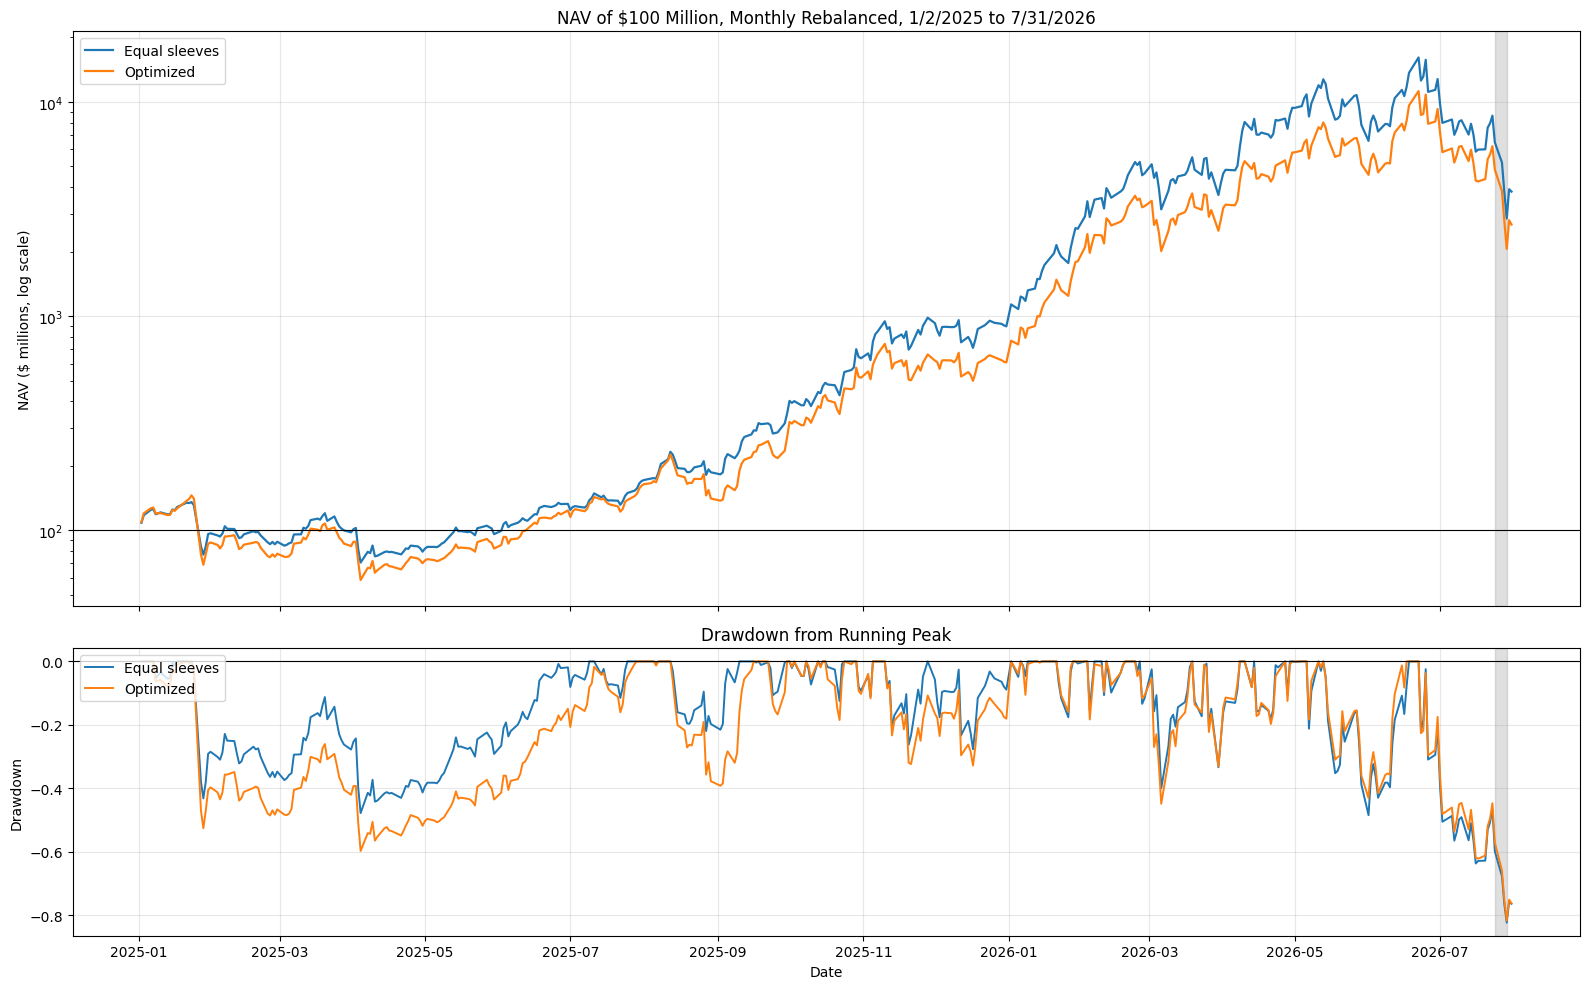

The shaded band is the 7/24/2026 to 7/29/2026 reversal examined in Part 6.1. NAV is drawn on a log scale because both books compound more than twenty-fold before the reversal.


In [60]:
#NAV of $100 million in each portfolio, with the drawdown underneath
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(nav_eq.index, nav_eq / 1e6, label="Equal sleeves", linewidth=1.6)
axes[0].plot(nav_opt.index, nav_opt / 1e6, label="Optimized", linewidth=1.6)
axes[0].set_yscale("log")
axes[0].set_ylabel("NAV ($ millions, log scale)")
axes[0].set_title("NAV of $100 Million, Monthly Rebalanced, 1/2/2025 to 7/31/2026")
axes[0].axhline(NAV / 1e6, color="black", linewidth=0.8)

for label, nav in [("Equal sleeves", nav_eq), ("Optimized", nav_opt)]:
    axes[1].plot(nav.index, nav / nav.cummax() - 1, label=label, linewidth=1.4)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].set_title("Drawdown from Running Peak")
axes[1].axhline(0, color="black", linewidth=0.8)

for ax in axes:
    ax.axvspan(pd.Timestamp("2026-07-24"), pd.Timestamp("2026-07-29"),
               color="grey", alpha=0.25)
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The shaded band is the 7/24/2026 to 7/29/2026 reversal examined in Part 6.1. "
      "NAV is drawn on a log scale because both books compound more than twenty-fold "
      "before the reversal.")

On the test period:

Over the 395 trading days from 1/2/2025 to 7/31/2026 the equal-sleeve book returns 3712.83% cumulatively and the optimized book 2575.76%, ending at $3.813 billion and $2.676 billion on a $100 million start. The optimizer loses on both halves of the ratio it was built to maximize: annualized mean is lower, 332.45% against 345.84%, and annualized volatility higher, 153.72% against 148.35%, giving a realized Sharpe of 2.163 against 2.331, a difference of -0.169.

The tail statistics point the same way. Maximum drawdown is almost identical, -81.68% against -82.30%, both bottoming on 7/29/2026 at the end of the reversal, but the optimized book's worst single day is materially worse, -45.25% against -35.96%, both on 1/27/2025. Concentrating the long sleeve into fewer, larger positions raised single-day tail risk without a compensating rise in average return. The magnitudes are extreme throughout because the mandate runs 400% gross with no financing or transaction costs, but the comparison between the two books is still valid, since both run the identical gross exposure over the identical days.

Part 5.2: Identify one period in which the two paths separate. Attribute the difference to weights and stock returns. State whether the optimizer benefited from information available before the period or from an outcome it could not have anticipated.

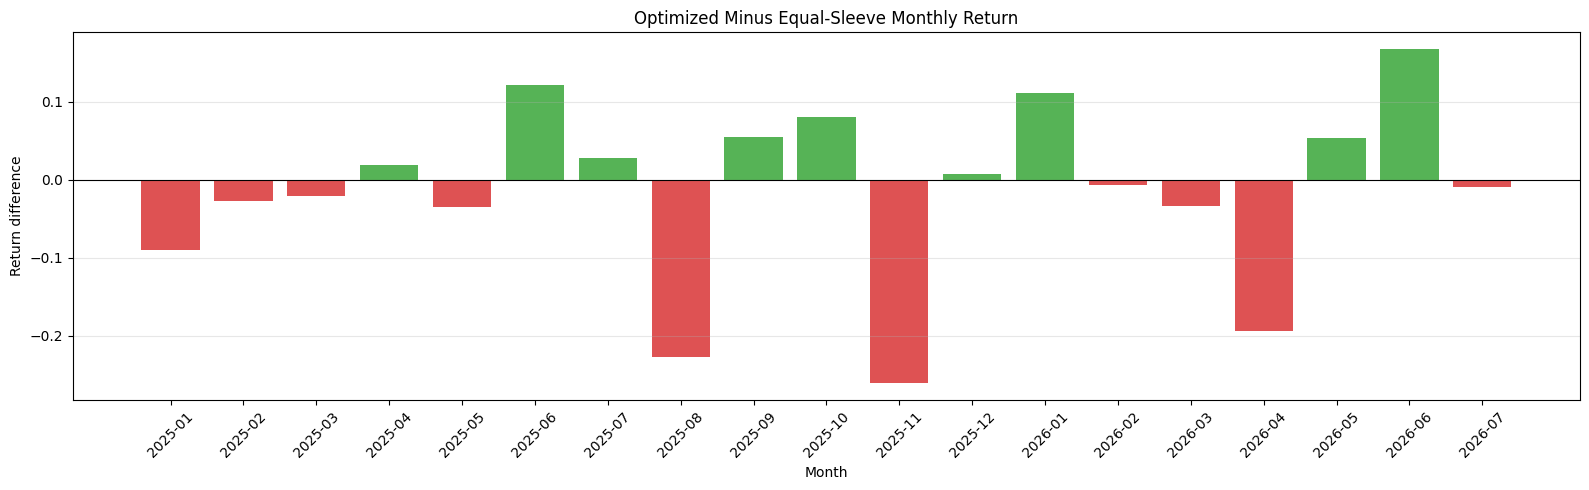

,Equal sleeves,Optimized,Difference
2025-01,-3.20%,-12.28%,-9.08%
2025-02,-8.72%,-11.48%,-2.76%
2025-03,+10.62%,+8.57%,-2.05%
2025-04,-18.72%,-16.84%,+1.88%
2025-05,+20.68%,+17.18%,-3.51%
2025-06,+38.48%,+50.61%,+12.13%
2025-07,+28.02%,+30.75%,+2.73%
2025-08,+9.70%,-13.07%,-22.77%
2025-09,+88.16%,+93.65%,+5.49%
2025-10,+81.17%,+89.20%,+8.02%


In [61]:
#month by month, where do the two paths separate
monthly = pd.DataFrame({"Equal sleeves": r_eq, "Optimized": r_opt})
monthly = monthly.groupby([monthly.index.year, monthly.index.month]).apply(
    lambda block: (1 + block).prod() - 1
)
monthly.index = [f"{y}-{m:02d}" for y, m in monthly.index]
monthly["Difference"] = monthly["Optimized"] - monthly["Equal sleeves"]

fig, ax = plt.subplots(figsize=(16, 5))

colors = ["tab:red" if v < 0 else "tab:green" for v in monthly["Difference"]]
ax.bar(monthly.index, monthly["Difference"], color=colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Optimized Minus Equal-Sleeve Monthly Return")
ax.set_ylabel("Return difference")
ax.set_xlabel("Month")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

display(monthly.style.format("{:+.2%}"))

In [62]:
#the largest separation, attributed to weights and stock returns
gap_month = monthly["Difference"].abs().idxmax()
gap_set_date = pd.Timestamp("2025-10-31")
gap_end = pd.Timestamp("2025-11-28")

gap_window = stock_returns.loc[
    (stock_returns.index > gap_set_date) & (stock_returns.index <= gap_end)
]

w_gap = weights_opt.loc[gap_set_date]
stock_window_return = (1 + gap_window).prod() - 1

attribution = pd.DataFrame({
    "Weight (optimized)": w_gap,
    "Weight (equal)": w_equal.reindex(stocks),
    "Weight difference": w_gap - w_equal.reindex(stocks),
    "Stock return": stock_window_return,
    "Contribution (optimized)": (gap_window * w_gap).sum(),
    "Contribution (equal)": (gap_window * w_equal.reindex(stocks)).sum()
})
attribution["Attributed difference"] = (
    attribution["Contribution (optimized)"] - attribution["Contribution (equal)"]
)
attribution = attribution.sort_values("Attributed difference")

print(f"Largest monthly separation: {gap_month}, weights set at {gap_set_date.date()}, "
      f"held through {gap_end.date()} ({len(gap_window)} trading days)")
print(f"Equal sleeves {monthly.loc[gap_month, 'Equal sleeves']:+.2%}, "
      f"optimized {monthly.loc[gap_month, 'Optimized']:+.2%}, "
      f"difference {monthly.loc[gap_month, 'Difference']:+.2%}")
print(f"Long sleeve accounts for {attribution['Attributed difference'][long_tickers].sum():+.2%}, "
      f"short sleeve for {attribution['Attributed difference'][short_tickers].sum():+.2%}")

display(
    attribution.style.format({
        "Weight (optimized)": "{:.2%}",
        "Weight (equal)": "{:.2%}",
        "Weight difference": "{:+.2%}",
        "Stock return": "{:+.2%}",
        "Contribution (optimized)": "{:+.2%}",
        "Contribution (equal)": "{:+.2%}",
        "Attributed difference": "{:+.2%}"
    })
)

Largest monthly separation: 2025-11, weights set at 2025-10-31, held through 2025-11-28 (19 trading days)
Equal sleeves +54.65%, optimized +28.52%, difference -26.14%
Long sleeve accounts for -18.35%, short sleeve for -0.78%


,Weight (optimized),Weight (equal),Weight difference,Stock return,Contribution (optimized),Contribution (equal),Attributed difference
LITE,0.00%,33.33%,-33.33%,+61.32%,+0.00%,+18.32%,-18.32%
NOW,-2.06%,-33.33%,+31.27%,-11.63%,+0.25%,+4.05%,-3.80%
MDB,-15.74%,-33.33%,+17.59%,-7.63%,+1.17%,+2.48%,-1.31%
BE,41.67%,33.33%,+8.34%,-17.34%,-5.42%,-4.34%,-1.08%
VRT,50.00%,33.33%,+16.67%,-6.77%,-2.75%,-1.83%,-0.92%
COHR,30.25%,33.33%,-3.08%,+24.48%,+7.72%,+8.51%,-0.79%
MU,28.08%,33.33%,-5.26%,+5.68%,+2.24%,+2.66%,-0.42%
ORCL,-32.20%,-33.33%,+1.13%,-23.10%,+8.17%,+8.46%,-0.29%
ADBE,-50.00%,-33.33%,-16.67%,-5.93%,+2.95%,+1.97%,+0.98%
WDAY,-50.00%,-33.33%,-16.67%,-10.13%,+5.00%,+3.33%,+1.67%


In [63]:
#what the 10/31/2025 estimates said about LITE against what LITE then did
lens = pd.DataFrame({
    "Est. mean (10/31/2025)": mu_hist.loc[gap_set_date],
    "Est. vol (10/31/2025)": vol_hist.loc[gap_set_date],
    "Est. Sharpe (10/31/2025)": mu_hist.loc[gap_set_date] / vol_hist.loc[gap_set_date],
    "Weight set": weights_opt.loc[gap_set_date],
    "Realized November return": stock_window_return,
    "Est. mean (11/28/2025)": mu_hist.loc[gap_end],
    "Weight set next month": weights_opt.loc[gap_end]
}).loc[long_tickers]

lens.style.format({
    "Est. mean (10/31/2025)": "{:.2%}",
    "Est. vol (10/31/2025)": "{:.2%}",
    "Est. Sharpe (10/31/2025)": "{:.3f}",
    "Weight set": "{:.2%}",
    "Realized November return": "{:+.2%}",
    "Est. mean (11/28/2025)": "{:.2%}",
    "Weight set next month": "{:.2%}"
})

,Est. mean (10/31/2025),Est. vol (10/31/2025),Est. Sharpe (10/31/2025),Weight set,Realized November return,Est. mean (11/28/2025),Weight set next month
SNDK,82.90%,54.48%,1.522,50.00%,+12.02%,87.84%,50.00%
MU,59.40%,49.66%,1.196,28.08%,+5.68%,59.83%,13.87%
VRT,104.47%,60.07%,1.739,50.00%,-6.77%,104.25%,50.00%
LITE,49.85%,56.27%,0.886,0.00%,+61.32%,77.07%,45.48%
COHR,66.01%,64.05%,1.031,30.25%,+24.48%,71.90%,16.63%
BE,97.63%,82.38%,1.185,41.67%,-17.34%,87.33%,24.02%


On the separation:

The two paths separate most sharply in November 2025, the month held on the weights set at the 10/31/2025 close, when equal sleeves return +54.65% and the optimized book +28.52%, a gap of -26.14 percentage points. The short sleeve explains almost none of it at -0.78pp, and one name explains nearly all of the -18.35pp long-sleeve gap: the optimizer held 0% of LITE while equal sleeves held +33.33%, and LITE returned +61.32%, worth -18.32pp on its own. Smaller items follow, with the nearly closed NOW short costing -3.80pp and the halved MDB short costing -1.31pp, while the deeper CRM, WDAY and ADBE shorts and the +50% SNDK position added back about +7.8pp between them.

This was an outcome the optimizer could not have anticipated, and the evidence is in its own inputs. At the 10/31/2025 estimate date LITE carried the lowest estimated Sharpe in the long sleeve, 0.886 against 1.739 for VRT and 1.522 for SNDK, so zeroing it was the correct response to the information available before the period, and nothing in the trailing 756-day window pointed at a 61% month. By the 11/28/2025 re-estimate that move had entered the window, LITE's estimated mean had jumped from 49.85% to 77.07%, and the optimizer bought 45.48% of LITE after the return had already been earned. The rule sells what has been weak and buys what has just been strong, one month late, which is the same defect that produced the 401% turnover in Part 4.2.

Part 6.1: For the July 24 through July 29, 2026 reversal, report the return and dollar P&L of each portfolio. Attribute each result to the long sleeve, short sleeve, and three largest stock contributions. Explain which earlier weight decisions mattered most.

In [64]:
#the reversal window; the weights in force were set at the 6/30/2026 close
reversal = stock_returns.loc["2026-07-24":"2026-07-29"]
w_reversal = weights_opt.loc[pd.Timestamp("2026-06-30")]

print(f"Reversal window: {len(reversal)} trading days, "
      f"{[d.date().isoformat() for d in reversal.index]}")

daily_reversal = pd.DataFrame({
    "Equal sleeves": reversal @ w_equal.reindex(stocks),
    "Optimized": reversal @ w_reversal
})

display(daily_reversal.style.format("{:+.2%}"))

reversal_summary = pd.DataFrame({
    label: {
        "Window return": (1 + daily_reversal[label]).prod() - 1,
        "P&L on $100m NAV ($)": NAV * ((1 + daily_reversal[label]).prod() - 1),
        "Worst day in window": daily_reversal[label].min()
    }
    for label in daily_reversal.columns
})

display(
    reversal_summary.style.format(
        lambda v: f"{v:,.0f}" if abs(v) > 100 else f"{v:+.2%}"
    )
)

Reversal window: 4 trading days, ['2026-07-24', '2026-07-27', '2026-07-28', '2026-07-29']


,Equal sleeves,Optimized
Date,,
2026-07-24 00:00:00,-24.89%,-22.33%
2026-07-27 00:00:00,-19.58%,-20.66%
2026-07-28 00:00:00,-27.40%,-27.55%
2026-07-29 00:00:00,-24.53%,-25.83%


,Equal sleeves,Optimized
Window return,-66.91%,-66.89%
P&L on $100m NAV ($),"-66,905,479","-66,886,066"
Worst day in window,-27.40%,-27.55%


In [65]:
#attribute each window result to the two sleeves and to individual stocks
stock_reversal_return = (1 + reversal).prod() - 1

contributions = pd.DataFrame({
    "Stock return": stock_reversal_return,
    "Weight (equal)": w_equal.reindex(stocks),
    "Contribution (equal)": (reversal * w_equal.reindex(stocks)).sum(),
    "Weight (optimized)": w_reversal,
    "Contribution (optimized)": (reversal * w_reversal).sum()
})

sleeves = pd.DataFrame({
    "Equal sleeves": {
        "Long sleeve": contributions["Contribution (equal)"][long_tickers].sum(),
        "Short sleeve": contributions["Contribution (equal)"][short_tickers].sum(),
        "Total (sum of daily contributions)": contributions["Contribution (equal)"].sum()
    },
    "Optimized": {
        "Long sleeve": contributions["Contribution (optimized)"][long_tickers].sum(),
        "Short sleeve": contributions["Contribution (optimized)"][short_tickers].sum(),
        "Total (sum of daily contributions)": contributions["Contribution (optimized)"].sum()
    }
})

print("Sleeve attribution over the reversal window")
display(sleeves.style.format("{:+.2%}"))

print("\nThree largest stock contributions, equal sleeves")
display(
    contributions.nsmallest(3, "Contribution (equal)")[
        ["Weight (equal)", "Stock return", "Contribution (equal)"]
    ].assign(**{"P&L on $100m ($)": lambda f: NAV * f["Contribution (equal)"]})
    .style.format({
        "Weight (equal)": "{:.2%}",
        "Stock return": "{:+.2%}",
        "Contribution (equal)": "{:+.2%}",
        "P&L on $100m ($)": "{:,.0f}"
    })
)

print("\nThree largest stock contributions, optimized")
display(
    contributions.nsmallest(3, "Contribution (optimized)")[
        ["Weight (optimized)", "Stock return", "Contribution (optimized)"]
    ].assign(**{"P&L on $100m ($)": lambda f: NAV * f["Contribution (optimized)"]})
    .style.format({
        "Weight (optimized)": "{:.2%}",
        "Stock return": "{:+.2%}",
        "Contribution (optimized)": "{:+.2%}",
        "P&L on $100m ($)": "{:,.0f}"
    })
)

display(
    contributions.sort_values("Contribution (optimized)").style.format({
        "Stock return": "{:+.2%}",
        "Weight (equal)": "{:.2%}",
        "Contribution (equal)": "{:+.2%}",
        "Weight (optimized)": "{:.2%}",
        "Contribution (optimized)": "{:+.2%}"
    })
)

Sleeve attribution over the reversal window


,Equal sleeves,Optimized
Long sleeve,-63.58%,-64.83%
Short sleeve,-32.82%,-31.54%
Total (sum of daily contributions),-96.40%,-96.37%



Three largest stock contributions, equal sleeves


,Weight (equal),Stock return,Contribution (equal),P&L on $100m ($)
SNDK,33.33%,-36.91%,-14.46%,"-14,459,599"
COHR,33.33%,-29.11%,-10.94%,"-10,941,608"
LITE,33.33%,-27.74%,-10.40%,"-10,399,936"



Three largest stock contributions, optimized


,Weight (optimized),Stock return,Contribution (optimized),P&L on $100m ($)
SNDK,50.00%,-36.91%,-21.69%,"-21,689,398"
VRT,50.00%,-26.64%,-14.49%,"-14,490,158"
MU,44.63%,-25.37%,-12.51%,"-12,512,555"


,Stock return,Weight (equal),Contribution (equal),Weight (optimized),Contribution (optimized)
SNDK,-36.91%,33.33%,-14.46%,50.00%,-21.69%
VRT,-26.64%,33.33%,-9.66%,50.00%,-14.49%
MU,-25.37%,33.33%,-9.34%,44.63%,-12.51%
WDAY,+31.39%,-33.33%,-9.43%,-39.51%,-11.18%
ADBE,+24.16%,-33.33%,-7.41%,-50.00%,-11.12%
LITE,-27.74%,33.33%,-10.40%,32.04%,-10.00%
CRM,+20.04%,-33.33%,-6.23%,-50.00%,-9.35%
BE,-24.64%,33.33%,-8.78%,23.33%,-6.14%
MDB,+7.34%,-33.33%,-2.40%,-10.49%,-0.76%
COHR,-29.11%,33.33%,-10.94%,0.00%,+0.00%


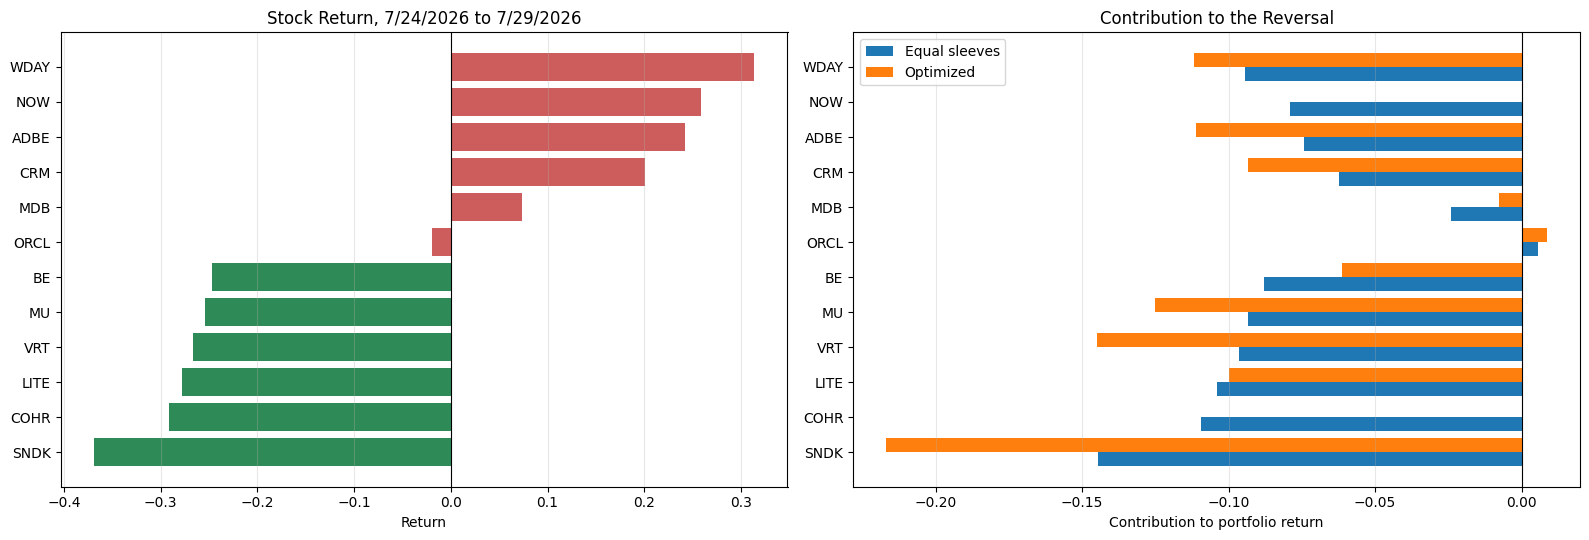

On the left, green is the long sleeve and red the short sleeve. Every long fell and every short except ORCL rose, so both legs lost money at the same time.


In [66]:
#the whole reversal in one picture: every stock return, and what each book held into it
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

order = stock_reversal_return.sort_values().index

axes[0].barh(order, stock_reversal_return.loc[order],
             color=["seagreen" if t in long_tickers else "indianred" for t in order])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Stock Return, 7/24/2026 to 7/29/2026")
axes[0].set_xlabel("Return")

width = 0.4
positions = np.arange(len(order))
axes[1].barh(positions - width / 2, contributions["Contribution (equal)"].loc[order],
             height=width, label="Equal sleeves")
axes[1].barh(positions + width / 2, contributions["Contribution (optimized)"].loc[order],
             height=width, label="Optimized")
axes[1].set_yticks(positions)
axes[1].set_yticklabels(order)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Contribution to the Reversal")
axes[1].set_xlabel("Contribution to portfolio return")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("On the left, green is the long sleeve and red the short sleeve. Every long fell and "
      "every short except ORCL rose, so both legs lost money at the same time.")

On the reversal:

Over the four trading days from 7/24/2026 to 7/29/2026 the equal-sleeve portfolio returns -66.91% and the optimized portfolio -66.89%, a P&L of -$66.91 million and -$66.89 million on $100 million of NAV. Both legs fail at once, which is what makes the window so expensive at 400% gross: all six longs fell, from SNDK at -36.91% to BE at -24.64%, and five of the six shorts rose, from MDB at +7.34% to WDAY at +31.39%, with only ORCL down -1.92%. The long sleeve contributes -63.58% for equal sleeves and -64.83% for the optimized book, and the short sleeve -32.82% and -31.54%. The three largest stock contributions are SNDK at -14.46%, COHR at -10.94% and LITE at -10.40% for equal sleeves, where the ranking follows the stock moves because every weight is the same, and SNDK at -21.69%, VRT at -14.49% and MU at -12.51% for the optimized book, where it follows the weights instead.

The earlier weight decisions that mattered most nearly cancel. Pinning SNDK at the +50% cap cost an extra 7.2pp relative to an equal 33.33% weight, since SNDK fell hardest of anything in the book, and holding VRT at the cap cost a further 4.8pp. Against that, zeroing COHR avoided a -29.11% name entirely for about +10.9pp, holding ORCL at the full -50% short produced the only profitable position in either portfolio at +0.87%, or +$0.87m, and trimming MDB to -10.49% and WDAY to -39.51% reduced exposure to two shorts that rose. The net of all of it is 2 basis points, so the optimizer's concentration neither protected it nor sank it. A position cap redistributes exposure within a long-short book but cannot help when the entire spread reverses at once, because the cap constrains individual positions and never touches the 400% gross or the zero net that the mandate fixes.

Part 6.2: Apply the two criteria declared in Section 2. Choose equal sleeves or your optimized allocation at the July 31, 2026 close. Report the weights you would use. Name one observable result over the next year that would reverse the choice and state how you would measure it.

In [67]:
#apply the two ex-ante criteria from Part 2.2, exactly as they were written
sharpe_eq = performance(r_eq)["Sharpe ratio"]
sharpe_opt = performance(r_opt)["Sharpe ratio"]
sharpe_gap = sharpe_opt - sharpe_eq

scorecard = pd.DataFrame([
    {
        "Criterion": "1. Annualized one-way turnover <= 300% of NAV",
        "Threshold": "<= 300.00%",
        "Realized": f"{turnover_annualized:.2%}",
        "Margin": f"{turnover_annualized - 3.0:+.2%}",
        "Result": "PASS" if turnover_annualized <= 3.0 else "FAIL"
    },
    {
        "Criterion": "2. Realized Sharpe exceeds equal sleeves by >= 0.20",
        "Threshold": ">= +0.200",
        "Realized": f"{sharpe_gap:+.3f}",
        "Margin": f"{sharpe_gap - 0.20:+.3f}",
        "Result": "PASS" if sharpe_gap >= 0.20 else "FAIL"
    }
]).set_index("Criterion")

display(scorecard)

both_pass = (turnover_annualized <= 3.0) and (sharpe_gap >= 0.20)
print(f"Equal sleeves Sharpe {sharpe_eq:.3f}, optimized Sharpe {sharpe_opt:.3f}")
print(f"Both criteria satisfied: {both_pass}")
print(f"Decision: {'replace equal sleeves with the optimized allocation' if both_pass else 'retain the equal-sleeve allocation'}")

,Threshold,Realized,Margin,Result
Criterion,,,,
1. Annualized one-way turnover <= 300% of NAV,<= 300.00%,401.04%,+101.04%,FAIL
2. Realized Sharpe exceeds equal sleeves by >= 0.20,>= +0.200,-0.169,-0.369,FAIL


Equal sleeves Sharpe 2.331, optimized Sharpe 2.163
Both criteria satisfied: False
Decision: retain the equal-sleeve allocation


In [68]:
#the allocation carried at the 7/31/2026 close, against the optimized allocation it replaces
w_recommended = w_equal.reindex(stocks) if not both_pass else weights_opt.loc[FINAL_DATE]

allocation = pd.DataFrame({
    "Side": ["long"] * 6 + ["short"] * 6,
    "Recommended weight": w_recommended,
    "Position on $100m NAV ($)": NAV * w_recommended,
    "Optimized weight (7/31/2026)": weights_opt.loc[FINAL_DATE],
    "Optimized position ($)": NAV * weights_opt.loc[FINAL_DATE]
})

display(
    allocation.style.format({
        "Recommended weight": "{:.2%}",
        "Position on $100m NAV ($)": "{:,.2f}",
        "Optimized weight (7/31/2026)": "{:.2%}",
        "Optimized position ($)": "{:,.2f}"
    })
)

print("Recommended allocation, exposure check")
print(f"Long:   {w_recommended[long_tickers].sum():.2%}")
print(f"Short:  {w_recommended[short_tickers].sum():.2%}")
print(f"Gross:  {w_recommended.abs().sum():.2%}")
print(f"Net:    {w_recommended.sum():.2%}")
print(f"Largest absolute position: {w_recommended.abs().max():.2%}")

,Side,Recommended weight,Position on $100m NAV ($),Optimized weight (7/31/2026),Optimized position ($)
SNDK,long,33.33%,"33,333,333.33",50.00%,"50,000,000.00"
MU,long,33.33%,"33,333,333.33",33.36%,"33,356,346.83"
VRT,long,33.33%,"33,333,333.33",50.00%,"50,000,000.00"
LITE,long,33.33%,"33,333,333.33",44.97%,"44,965,979.52"
COHR,long,33.33%,"33,333,333.33",0.00%,0.00
BE,long,33.33%,"33,333,333.33",21.68%,"21,677,673.66"
ADBE,short,-33.33%,"-33,333,333.33",-50.00%,"-50,000,000.00"
CRM,short,-33.33%,"-33,333,333.33",-50.00%,"-50,000,000.00"
ORCL,short,-33.33%,"-33,333,333.33",-50.00%,"-50,000,000.00"
NOW,short,-33.33%,"-33,333,333.33",-0.00%,-0.00


Recommended allocation, exposure check
Long:   200.00%
Short:  -200.00%
Gross:  400.00%
Net:    0.00%
Largest absolute position: 33.33%


Part 6.2 decision:

Both criteria declared in Part 2.2 fail, so we retain the equal-sleeve allocation at the 7/31/2026 close. Annualized one-way turnover is 401.04% of NAV against the 300% ceiling, and realized Sharpe falls short of equal sleeves by 0.169 against a required improvement of at least 0.20. Neither is a near miss: turnover overshoots by 101 percentage points on trades that bought about +0.06 of estimated Sharpe, and the return criterion fails in the wrong direction outright, since the optimized book delivered less risk-adjusted return than the portfolio it was meant to replace, with a lower mean, a higher volatility and a worse single worst day. The weights we would use are therefore the baseline equal sleeves, +33.33% of NAV or $33,333,333 long in each of SNDK, MU, VRT, LITE, COHR and BE, and -33.33% or -$33,333,333 short in each of ADBE, CRM, ORCL, NOW, WDAY and MDB, giving +200% long, -200% short, 400% gross and 0% net. We are declining this particular allocation, not rejecting the optimizer as a tool.

The result that would reverse the choice is the same two criteria passing on a fresh sample. We would run both books forward on paper from 8/3/2026 through 7/31/2027 under identical rules, meaning trailing 756 daily returns, month-end re-estimation and weights held over the following month, and switch only if the optimized book's annualized one-way turnover over those twelve rebalances is at or below 300% of NAV and its realized Sharpe, computed as annualized mean over annualized volatility with a zero risk-free rate, exceeds the equal-sleeve Sharpe over the same days by at least 0.20. The most informative thing to watch inside that test is whether the cap stops binding, measured as the count of positions whose absolute weight lies strictly between zero and 50% at each month-end, since it was the pinning of most weights that forced the monthly adjustment into two or three names and produced the 401% turnover. We would not revise the thresholds themselves, which were fixed before any post-2024 return was calculated.